# Mean number of Wolbachia-infected mosquitoes per household under the 4 single release scenarios
## Abby Barlow, The University of Bath
Uses 'SSA_rel_com_fem_switch.jl' for the stochastic simulation of the community scale releases and 'SSA_rel_hhold_fem_switch.jl' for household scale releases which are called in 'Single_release_sep_file.jl'.

To use the already produced results see 'Initial_release_experiments.csv' for the required zip file names.

Import libraries

In [1]:
### importing the required libraries
using CSV
using DataFrames
using Statistics
using Plots
using Tar
using CodecZlib

Import required scripts

In [2]:
module Read
    include("Read_data_files.jl")
end

module Check
    include("Check_files_exist.jl")
end

Main.Check

### Key simulation parameters

JOB_ID defines the job run from the HPC and is used to identify each set of results. These are detailed in 'Initial_release_experiments.csv'.

gamma, rho, tau and alpha are the mosquito dispersal parameters.

num_simulations defines the number of simulation runs of the SSA for each result.

rel_type defines the release scale. 'relhhold' is for household scale releases and 'relcom' is for community scale releases.

In [3]:
### change this to the job id for the experiment you want to analyze
## or the name you want to give the folder where all the extracted data files will be stored
JOB_ID = 67114154
### make sure to write dispersal parameters as floats to keep file name consistent ###

## vary these for different dispersal scenarios
gamma = 0.15    # dispersal rate from release site to household
rho = 0.33      # rate visit the households
tau = 0.33      # rate leave the households
alpha = 0.1     # dispersal rate of females moving from household directly to another household

num_simulations = 100  # number of realisations of SSA to run, 10,000 is a good number for the paper
rel_type = "relcom"  # release scale

"relcom"

Function to extract zip files

In [4]:
# # Define the file path
# file_path = "Initial_paper_results\\sim_results_$(JOB_ID).tar.gz" #

# # Extract the .tar.gz file
# function extract_tar_gz(file_path::String, dest_dir::String)
#     open(file_path) do io
#         tar_io = GzipDecompressorStream(io)
#         Tar.extract(tar_io, dest_dir)
#     end
# end

# # Define the destination directory
# dest_dir =  joinpath("Initial_paper_results","$(JOB_ID)")

# # Extract the files
# extract_tar_gz(file_path, dest_dir)

# println("Extraction complete. Files are extracted to $dest_dir.")

Parameter dictionary

In [5]:
fem_w0 = 0  # how many wildtypes and infected mosquitoes starting off with
male_w0 = 0
fem_m0 = 8
male_m0 = 8
# initialise free pool
m_free0 = 0 # no. of free wild-type
w_free0 = 0 # no. of free Wolbachia

phi = 0.85      # wolbachia fitness effect on birth rate
K = 30          # carrying capacity of mosquitoes per household
d = 12/100      # death rate of mosquitoes
k = 0.3         # larval density parameter
h = 0.19*100^k  # larval density parameter
b = 0.54        # per capita birth rate of mosquitoes (wildtypes)
H = 100         # number of households
u = 1           # vertical transmission probability
v = 1           # CI effect, proportion of non-viable offspring from infected male and wildtype female birth

rel_t = 150   # initial release time
delta_rel = 0 # time in days between releases, currently set to a single release inside the SSA code
## remember this is per household for the household releases so should use smaller release numbers
## currently set for community wide release
rel_size = 8*H # total number of Wolbachia-infected mosquitoes released into the community

t_start = 0    
t_end = 1000   # start time and end time (days) of simulation

result_length = length(t_start:t_end) # number of time points to store results
weeks = round(Int,result_length/7)    # number of weeks to store results

parameters = Dict(           # dictionary of parameters
    :fem_m0 => fem_m0,
    :male_m0 => male_m0,
    :fem_w0 => fem_w0,
    :male_w0 => male_w0,
    :m_free0 => m_free0,
    :w_free0 => w_free0,
    :rho => rho,
    :phi => phi,
    :b => b,
    :K => K,
    :d => d,
    :h => h,
    :k => k,
    :u => u,
    :v => v,
    :tau => tau,
    :H => H,
    :t_start => t_start,
    :t_end => t_end,
    :seed => 1234,
    :delta_rel => delta_rel,
    :rel_size => rel_size,
    :gamma => gamma,
    :alpha => alpha,
    :rel_t => rel_t
)

Dict{Symbol, Real} with 25 entries:
  :b        => 0.54
  :alpha    => 0.1
  :rel_size => 800
  :gamma    => 0.15
  :m_free0  => 0
  :rho      => 0.33
  :t_start  => 0
  :h        => 0.756404
  :rel_t    => 150
  :male_w0  => 0
  :fem_m0   => 8
  :K        => 30
  :phi      => 0.85
  :fem_w0   => 0
  :d        => 0.12
  :k        => 0.3
  :v        => 1
  :u        => 1
  :male_m0  => 8
  ⋮         => ⋮

Convert dispersal parameters to strings and return sum of Wolbachia-infected in each household over time and number of results.

In [6]:
alpha_str, gamma_str, rho_str, tau_str = Read.str_convert(alpha, gamma, rho, tau)

sum_array, ct = Check.check_file_exist(alpha_str, gamma_str, rho_str, tau_str, H, rel_t, rel_size, rel_type, num_simulations, JOB_ID)

# Compute the mean array
# this gives the mean over all sims for each household
if ct > 0
    mean_array_h = sum_array ./ ct
    println("Mean array computed successfully.")
else
    println("No valid data files found.")
end

Mean array computed successfully.


Reads in pre-processed data

In [7]:
mean_df = CSV.read(joinpath("../Initial_paper_results","mean_wolb_hhold_all.csv"), DataFrame)
mean_array_015 = mean_df[!, "mean_array_015"]
mean_array_033 = mean_df[!, "mean_array_033"]
mean_array_2 = mean_df[!, "mean_array_2"]
mean_array_h = mean_df[!, "mean_array_h"]

143-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 9.9147
 9.8998
 9.9433
 9.8847
 9.8224
 9.8335
 9.9024
 9.9018
 9.8944

Plots figure for mean number of Wolbachia-infected mosquitoes per household over time.

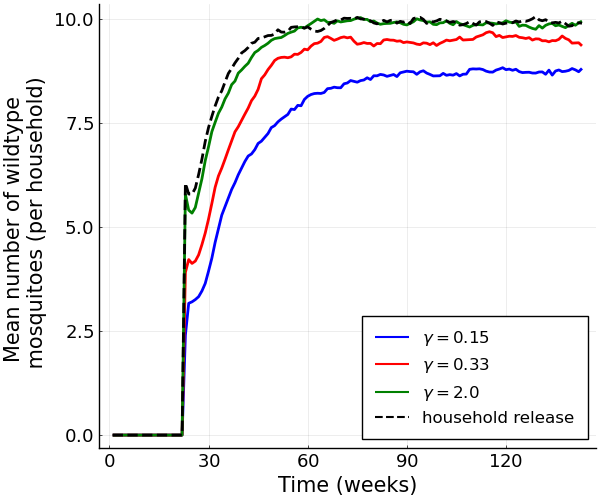

In [8]:
pyplot()  # using the pyplot backend for plotting

#Average number of Wolbachia-infected per household
# gamma = 0.15
p = plot(mean_array_015, xlabel="Time (weeks)", ylabel="Mean number of wildtype \n mosquitoes (per household)",
    titlefont=font(14), label="\$\\gamma=0.15\$",
    size = (600, 500),
    guidefont = font(15), 
    tickfont = font(13),
    linecolor=:blue,
    grid = true,
    linewidth=2)

# gamma = 0.33
plot!(p, mean_array_033, label="\$\\gamma=0.33\$",
size = (600, 500),
    guidefont = font(15), 
    tickfont = font(13),
    linecolor=:red,
    grid = true,
    linewidth=2)

# gamma = 2.0
plot!(p, mean_array_2, label="\$\\gamma=2.0\$",
size = (600, 500),
    guidefont = font(15), 
    tickfont = font(13),
    linecolor=:green,
    grid = true,
    linewidth=2)

# Add the household release result
plot!(p, mean_array_h, label="household release", linecolor=:black, linestyle=:dash,
size = (600, 500),
    guidefont = font(15), 
    tickfont = font(13),
    grid = true,
    linewidth=2,
    legendfont=font(12),
    legend=:bottomright)

# Save the plot
#savefig(p, "wild_per_house_01_gammas_033_033_100__150_8_relhhold.pdf")
#savefig(p, "wolb_per_house_01_gammas_033_033_100__150_8_relhhold.pdf")

# Display the plot
p

Saves pre-processed data to be reused

In [9]:
#= # Convert matrices to vectors (mean over households for each week)
mean_015 = mean(mean_array_015, dims=2)[:]
mean_033 = mean(mean_array_033, dims=2)[:]
mean_2   = mean(mean_array_2, dims=2)[:]
mean_h   = mean(mean_array_h, dims=2)[:]

df = DataFrame(
    week = 1:length(mean_015),
    mean_array_015 = mean_015,
    mean_array_033 = mean_033,
    mean_array_2   = mean_2,
    mean_array_h   = mean_h,
)

CSV.write("mean_wild_hhold_male.csv", df) =#

In [10]:
# # Convert matrices to vectors (mean over households for each week)
# mean_015 = mean(mean_array_015, dims=2)[:]
# mean_033 = mean(mean_array_033, dims=2)[:]
# mean_2   = mean(mean_array_2, dims=2)[:]
# mean_h   = mean(mean_array_h, dims=2)[:]

# df = DataFrame(
#     week = 1:length(mean_015),
#     mean_array_015 = mean_015,
#     mean_array_033 = mean_033,
#     mean_array_2   = mean_2,
#     mean_array_h   = mean_h,
# )

# CSV.write("mean_wolb_hhold_all.csv", df)